In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data.preprocessing import LogReturnPipeline
from sklearn.preprocessing import StandardScaler

In [55]:
stocks = ['KO', 'PEP', 'NVDA','KSU']
features = [f'mid_price_{s}' for s in stocks]
seq_len = 150

In [56]:
data = pd.read_csv('data/stocks/midprice_volume__KO_PEP_NVDA_KSU__train.csv', index_col=0)[features].values
data.shape

(68070, 4)

In [58]:
pipeline = LogReturnPipeline(StandardScaler())
data_processed = pipeline.preprocess(data)
data_processed.shape

(68069, 4)

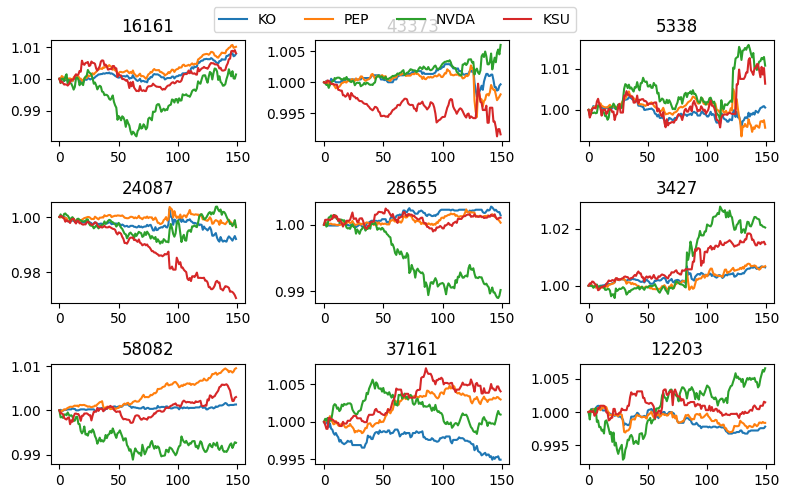

In [59]:
nrows, ncols = 3, 3
indices = np.random.choice(len(data)-seq_len, nrows*ncols, replace=False)

fig, axis = plt.subplots(nrows, ncols, figsize=(8, 5))
axis = axis.ravel()

add_label = True
for i, ax in zip(indices, axis):
    ax.set_title(i)
    ax.plot(data[i:i+seq_len] / data[i], label=stocks if add_label else None)
    add_label = False

fig.legend(ncols=4, loc='upper center')
fig.tight_layout()
plt.show()
plt.close(fig)

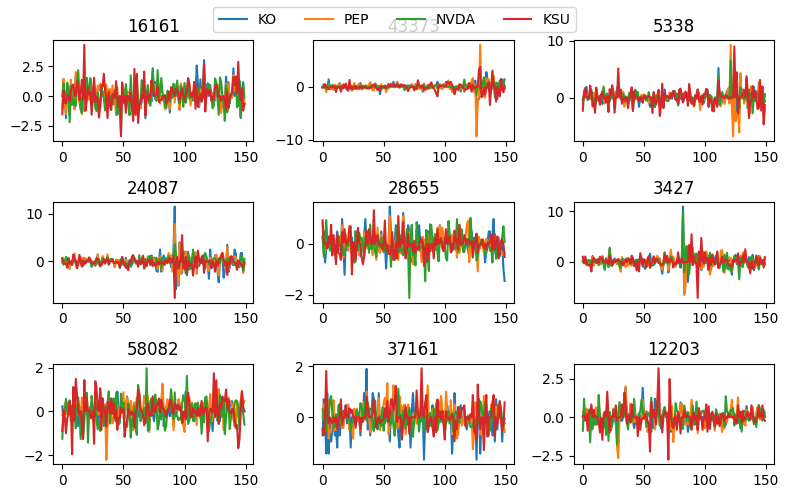

In [60]:
fig, axis = plt.subplots(nrows, ncols, figsize=(8, 5))
axis = axis.ravel()

add_label = True
for i, ax in zip(indices, axis):
    ax.set_title(i)
    ax.plot(data_processed[i:i+seq_len], label=stocks if add_label else None)
    add_label = False

fig.legend(ncols=4, loc='upper center')
fig.tight_layout()
plt.show()
plt.close(fig)